# Analysis of Concepts

In [1]:
import json
import pandas as pd

# requires the data from Zenodo
with open("data/divers1m_json/rich/divers1m.json", "r") as f:
    data = json.load(f)
    
df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)


## Missing Values

In [2]:
def get_nan_info(df, columns):
    n = len(df)
    for col in columns:
        if col.startswith("matched_"):
            n_empty = len(df[df[col].apply(len) == 0])
        else:
            n_empty = df[col].isna().sum()
        print(f"{col}: {n_empty:,} missing ({n_empty / n * 100:.2f}% of total {n})")
        
columns = [
    "tempo",
    "matched_instruments_groups",
    "matched_concepts",
    "matched_segments",
    "release_styles",
    "release_genres",
]

print("\nNaN info for full dataset")
get_nan_info(df, columns)

print("\nNaN info for DVI dataset")
get_nan_info(df[df.dvi], columns)



NaN info for full dataset
tempo: 69,417 missing (5.58% of total 1244810)
matched_instruments_groups: 763,629 missing (61.35% of total 1244810)
matched_concepts: 273,394 missing (21.96% of total 1244810)
matched_segments: 1,168,302 missing (93.85% of total 1244810)
release_styles: 804,611 missing (64.64% of total 1244810)
release_genres: 804,611 missing (64.64% of total 1244810)

NaN info for DVI dataset
tempo: 198 missing (0.04% of total 444821)
matched_instruments_groups: 291,038 missing (65.43% of total 444821)
matched_concepts: 1,388 missing (0.31% of total 444821)
matched_segments: 434,973 missing (97.79% of total 444821)
release_styles: 4,622 missing (1.04% of total 444821)
release_genres: 4,622 missing (1.04% of total 444821)


## Value Distributions

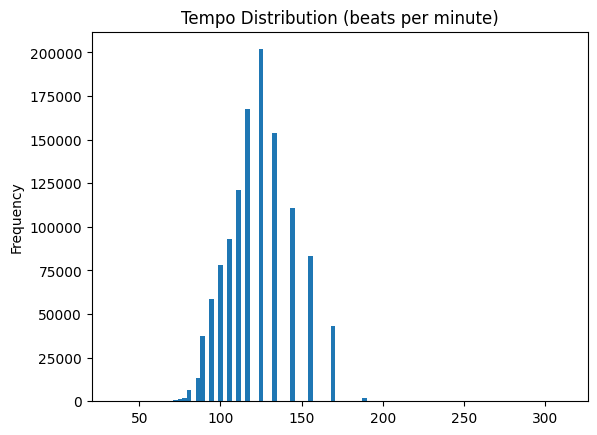

In [3]:
import matplotlib.pyplot as plt

df.tempo.plot(kind="hist", bins=100, title="Tempo Distribution (beats per minute)")
plt.show()


In [4]:
def parse_matched_dict(d):
    if isinstance(d, dict):
        return list({k for sub in d.values() for k in sub.keys()})
    return []

se_concepts = df.matched_concepts.apply(parse_matched_dict)
se_instruments = df.matched_instruments_groups.apply(parse_matched_dict)


Saved PDF: figures/matched_concepts.pdf


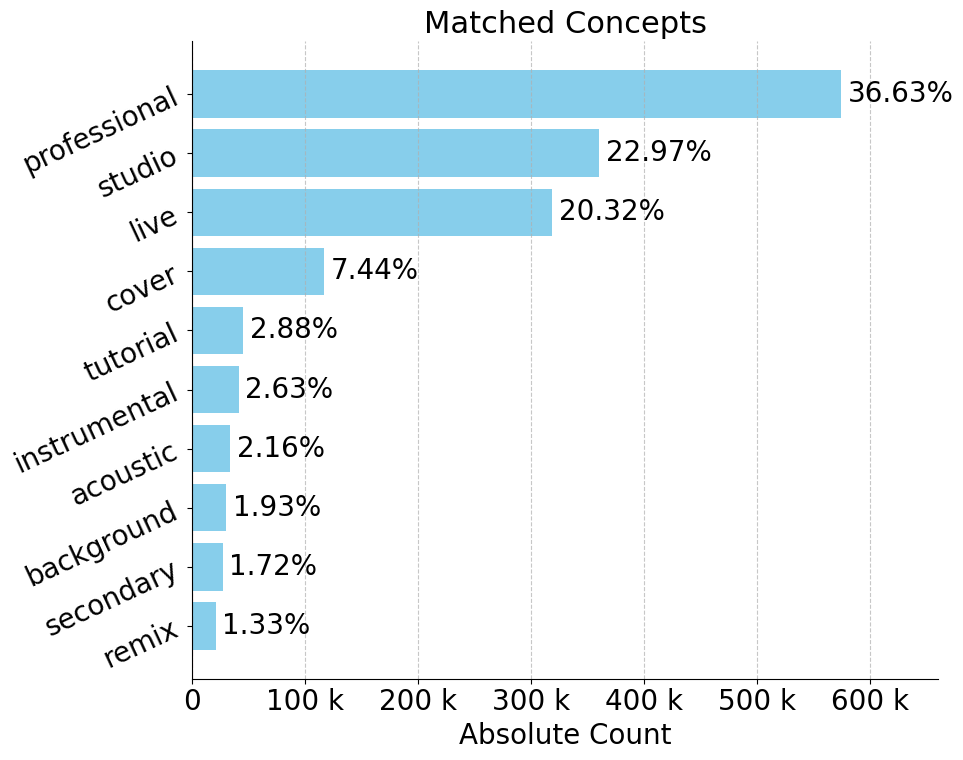

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter


def plot_string_counts_barh(series, label_name, top_n=None, vlines=None, out_file=None):
    """
    Plot a horizontal bar chart of value counts (absolute and relative) from a Series of lists,
    and optionally save it as a PDF with larger text.
    """
    counts = series.explode().value_counts()
    if top_n:
        counts = counts.head(top_n)
    relative = counts / counts.sum()

    # Set global font size for readability in PDF
    plt.rcParams.update({'font.size': 20})
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)
    bars = ax.barh(counts.index, counts.values, color='skyblue')

    # Add margin to prevent text overflow
    max_val = max(counts.values)
    ax.set_xlim(0, max_val * 1.15)  # Slightly more margin

    # Draw percentage labels with larger font
    for i, (abs_val, rel_val) in enumerate(zip(counts.values, relative.values)):
        ax.text(abs_val + max_val * 0.01, i, f"{rel_val:.2%}", va='center', fontsize=20)

    # Axis formatting
    ax.xaxis.set_major_formatter(EngFormatter(unit=''))
    ax.set_xlabel("Absolute Count", fontsize=20)
    ax.invert_yaxis()
    plt.yticks(rotation=25)

    # Remove top and right spines (frame lines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Optional vertical reference lines
    if vlines:
        for v in vlines:
            ax.axvline(x=v, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()

    # Optional PDF export
    if out_file:
        plt.savefig(out_file, format='pdf', bbox_inches='tight')
        print(f"Saved PDF: {out_file}")

    ax.set_title(f"Matched {label_name}", fontsize=22)
    plt.show()

plot_string_counts_barh(se_concepts, "Concepts", top_n=20, vlines=[0.01], out_file="figures/matched_concepts.pdf", )



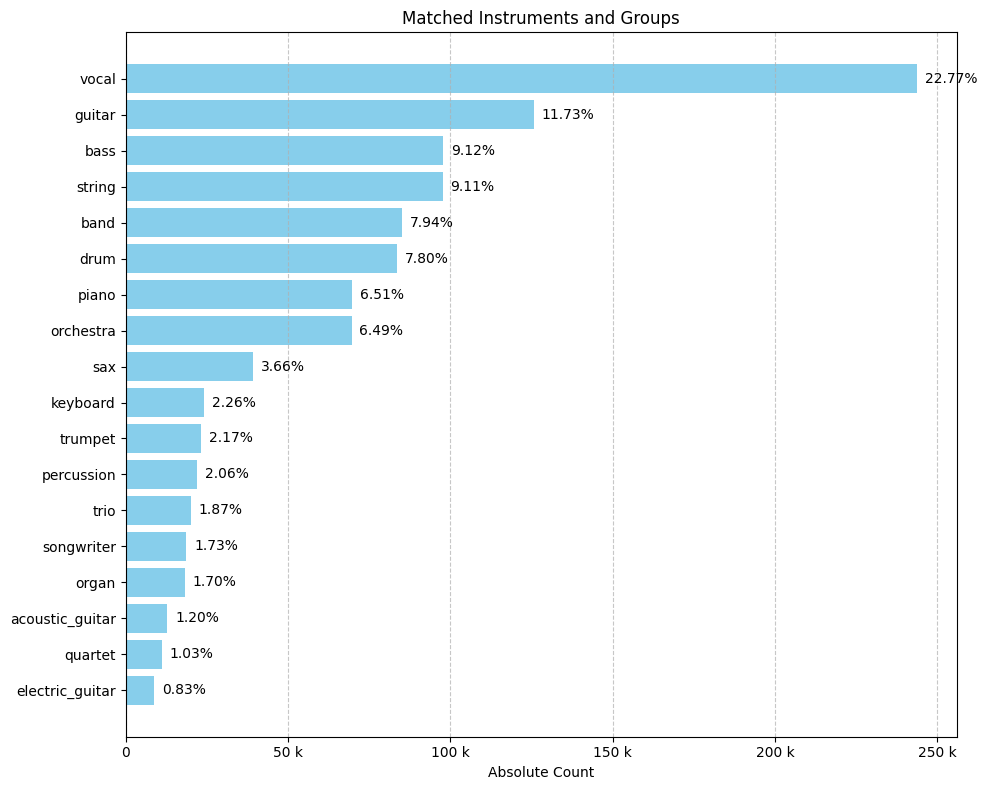

In [15]:
plot_string_counts_barh(se_instruments, "Instruments and Groups",)
